# Titanic survival prediction
## Assignment 1: From Dirty Data to Predictive Models

This notebook completes Steps 1–5 using the Kaggle Titanic data. It compares
Bernoulli Naive Bayes (including an unsmoothed control) with Linear Regression,
Ridge, and LASSO. All methods use the same stratified holdout and training folds.

**Run:** choose Restart Kernel and Run All. Keep `titanic/train.csv` and
`titanic/test.csv` next to this notebook, or upload those two files when prompted
in Google Colab. All code is organized into separate cells below. Generated tables, printed results, and figures are saved directly inside this notebook; no separate image or CSV files are written.

**Data roles:** `train.csv` contains labels; an internal 20% holdout is used for
evaluation. `test.csv` is used only for optional Kaggle predictions at the end.
`gender_submission.csv` is an example prediction file, not ground truth.

**Submission:** the accompanying 11-page PDF contains the analysis and plots.
Upload this notebook to Colab and put its shareable link on report page 1.
The AI disclosure at the end describes the assistance actually provided;
student review and any subsequent revisions must be recorded honestly.

In [1]:
from pathlib import Path
import json, sys, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, KBinsDiscretizer
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve)

In [2]:
SEED = 42
sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 180})
print('Python:', platform.python_version())
print('pandas:', pd.__version__, '| NumPy:', np.__version__,
      '| scikit-learn:', sklearn.__version__)

def show_figure(name):
    plt.tight_layout()
    plt.show()
    plt.close()

Python: 3.10.7
pandas: 2.2.1 | NumPy: 1.26.4 | scikit-learn: 1.4.1.post1


## Step 1 — Load and audit the data
The file contains 891 labeled passengers, not all people aboard the ship.
Survived is 0 for death and 1 for survival. PassengerId is an identifier;
Pclass and Embarked are categorical despite Pclass being stored as an integer.
SibSp and Parch count accompanying relatives. Inspect missingness, duplicates,
category spelling, ranges, zero fares, and high fares before preprocessing.

In [3]:
data_dir = next((p for p in [Path('titanic'), Path('.'), Path('/content/titanic'),
                            Path('/content')]
                 if (p / 'train.csv').exists()), None)
if data_dir is None:
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError('Place train.csv and test.csv in titanic/.') from exc
    print('Upload the Kaggle train.csv and test.csv files.')
    files.upload()
    data_dir = Path('.')

In [4]:
raw = pd.read_csv(data_dir / 'train.csv')
required = {'PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age',
            'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'}
assert required.issubset(raw.columns)
assert raw['Survived'].isin([0, 1]).all()
assert raw['PassengerId'].is_unique
print('Labeled data shape:', raw.shape)
display(raw.head())

Labeled data shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
audit = pd.DataFrame({'dtype': raw.dtypes.astype(str),
                      'missing': raw.isna().sum(),
                      'missing_pct': raw.isna().mean().mul(100),
                      'unique_nonmissing': raw.nunique()})
display(audit.round(2))
display(raw.describe().round(2))
print('Exact duplicate rows:', raw.duplicated().sum())
print('Sex categories:', raw.Sex.unique())
print('Embarked categories:', raw.Embarked.dropna().unique())
print('Class categories:', sorted(raw.Pclass.unique()))
print('Zero fares:', raw.Fare.eq(0).sum(), '| Maximum fare:', raw.Fare.max())
print('Rows retained by complete-case deletion:', len(raw.dropna()))

,dtype,missing,missing_pct,unique_nonmissing
PassengerId,int64,0,0.00,891
Survived,int64,0,0.00,2
Pclass,int64,0,0.00,3
Name,object,0,0.00,891
Sex,object,0,0.00,2
Age,float64,177,19.87,88
SibSp,int64,0,0.00,7
Parch,int64,0,0.00,7
Ticket,object,0,0.00,681
Fare,float64,0,0.00,248


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


Exact duplicate rows: 0
Sex categories: ['male' 'female']
Embarked categories: ['S' 'C' 'Q']
Class categories: [1, 2, 3]
Zero fares: 15 | Maximum fare: 512.3292
Rows retained by complete-case deletion: 183


### Cleaning decisions and leakage control
We retain passengers rather than deleting rows with missing Age or Cabin.
Age uses a training-only median; Embarked uses a training-only mode. Cabin is
replaced with a recorded-cabin indicator because its exact labels are sparse.
An AgeMissing indicator preserves information lost through imputation.

Whitespace is stripped and category case is standardized. Impossible negative
values and unsupported categories become missing, with their counts printed.
Plausible fractional infant ages, zero fares, and high fares are retained:
being unusual is not evidence of error. A log(1 + Fare) transform limits skew.
No survival labels are used to decide replacements.

The stratified 80/20 split happens before any fitted transformation. Every
cross-validation fold refits imputation, encoding, bin edges, and scaling.
The held-out set is evaluated only after model settings are selected by
five-fold training cross-validation. Overall schema/missingness checks above
do not estimate any preprocessing parameters.

In [6]:
X_raw = raw.drop(columns='Survived')
y = raw.Survived.astype(int)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=SEED, stratify=y)
assert set(X_train_raw.PassengerId).isdisjoint(X_test_raw.PassengerId)
split_summary = pd.DataFrame({
    'partition': ['Training', 'Holdout'],
    'n': [len(y_train), len(y_test)],
    'survivors': [int(y_train.sum()), int(y_test.sum())],
    'survival_rate': [y_train.mean(), y_test.mean()]})
display(split_summary.round(4))

,partition,n,survivors,survival_rate
0,Training,712,273,0.3834
1,Holdout,179,69,0.3855


In [7]:
def clean_and_engineer(frame):
    # All operations here are row-wise; no population statistics are fitted.
    d = frame.copy()
    d['Sex'] = d.Sex.str.strip().str.lower()
    d['Embarked'] = d.Embarked.str.strip().str.upper()
    for col, allowed in [('Sex', ['male', 'female']),
                         ('Embarked', ['S', 'C', 'Q']), ('Pclass', [1, 2, 3])]:
        d.loc[~d[col].isin(allowed), col] = np.nan
    for col in ['Age', 'Fare', 'SibSp', 'Parch']:
        d[col] = pd.to_numeric(d[col], errors='coerce')
        d.loc[d[col] < 0, col] = np.nan
    d['AgeMissing'] = d.Age.isna().astype(int)
    d['HasCabin'] = d.Cabin.fillna('').str.strip().ne('').astype(int)
    d['FamilySize'] = d.SibSp + d.Parch + 1
    d['IsAlone'] = d.FamilySize.eq(1).astype(int)
    d['LogFare'] = np.log1p(d.Fare)
    # Keep only interpretable predictors; no identifiers or target enter X.
    return d[['Age', 'LogFare', 'Pclass', 'Sex', 'Embarked',
              'FamilySize', 'IsAlone', 'HasCabin', 'AgeMissing']]

In [8]:
X_train = clean_and_engineer(X_train_raw)
X_test = clean_and_engineer(X_test_raw)
invalid = {c: int((pd.to_numeric(raw[c], errors='coerce') < 0).sum())
           for c in ['Age', 'Fare', 'SibSp', 'Parch']}
invalid.update({'unsupported_sex': int((~raw.Sex.isin(['male','female'])).sum()),
                'unsupported_port': int((raw.Embarked.notna() &
                    ~raw.Embarked.isin(['S','C','Q'])).sum()),
                'unsupported_class': int((~raw.Pclass.isin([1,2,3])).sum())})
print('Invalid-value audit:', invalid)
assert all(v == 0 for v in invalid.values())

Invalid-value audit: {'Age': 0, 'Fare': 0, 'SibSp': 0, 'Parch': 0, 'unsupported_sex': 0, 'unsupported_port': 0, 'unsupported_class': 0}


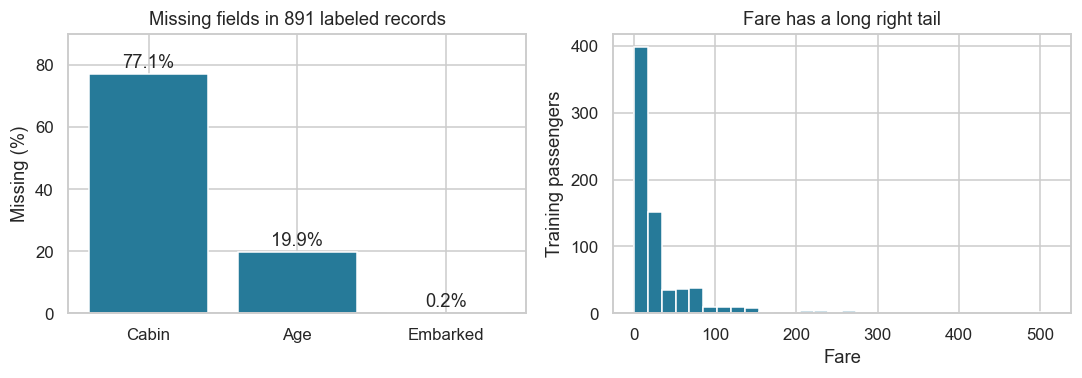

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
miss = raw.isna().mean().mul(100).sort_values(ascending=False)
miss = miss[miss > 0]
axes[0].bar(miss.index, miss.values, color='#267a99')
axes[0].set(ylabel='Missing (%)', title='Missing fields in 891 labeled records', ylim=(0, 90))
for i, v in enumerate(miss.values):
    axes[0].text(i, v+2, f'{v:.1f}%', ha='center')
axes[1].hist(X_train_raw.Fare, bins=30, color='#267a99')
axes[1].set(xlabel='Fare', ylabel='Training passengers', title='Fare has a long right tail')
show_figure('01_data_audit.png')

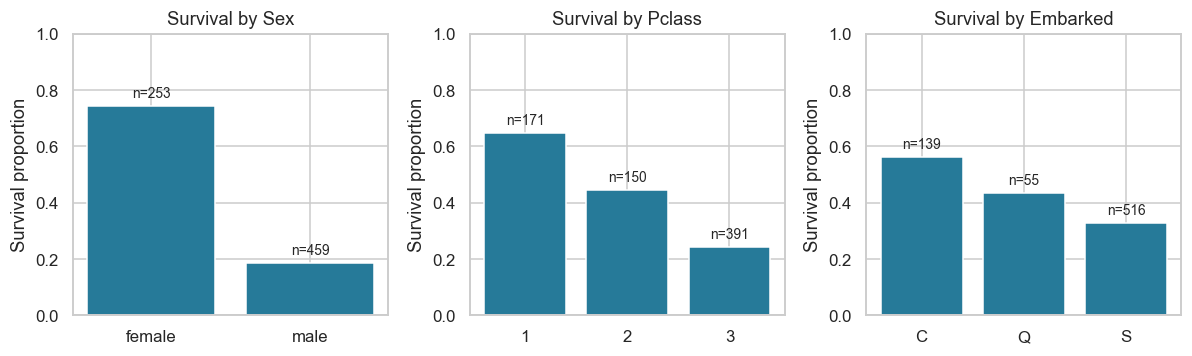

In [10]:
eda = X_train_raw.assign(Survived=y_train)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, col in zip(axes, ['Sex', 'Pclass', 'Embarked']):
    grouped = eda.groupby(col).Survived.agg(['mean', 'count'])
    ax.bar(grouped.index.astype(str), grouped['mean'], color='#267a99')
    ax.set(title=f'Survival by {col}', ylabel='Survival proportion', ylim=(0,1))
    for i, row in enumerate(grouped.itertuples()):
        ax.text(i, row.mean + .03, f'n={row.count}', ha='center', fontsize=9)
show_figure('02_training_patterns.png')

## Step 2 — Feature engineering and model-specific preprocessing
**Linear models:** median-imputed Age, LogFare, and FamilySize are standardized
using training means and standard deviations. Sex, Pclass, and Embarked are
mode-imputed and one-hot encoded with a reference level dropped. IsAlone,
HasCabin, and AgeMissing remain 0/1. This allows a different effect for a person
traveling alone without imposing a single linear family-size effect.

**Bernoulli NB:** Age, LogFare, and FamilySize are median-imputed and placed in
three training-derived quantile bins, each represented by binary indicators.
Duplicate quantile edges can reduce the number of bins (especially FamilySize).
Categorical variables are fully one-hot encoded; the three flags remain binary.
Bernoulli NB models both the presence and absence of each binary indicator.

Name, Ticket, PassengerId, and raw Cabin are excluded to avoid memorizing sparse
identifiers. FamilySize = SibSp + Parch + 1 replaces the two relative counts.
An ablation removes FamilySize, IsAlone, HasCabin, and AgeMissing to check whether
these engineered features actually help on training validation folds.

One-hot bins are dependent and Fare, class, and Cabin recording can overlap in
information. This violates NB's conditional-independence assumption; accuracy
can still be useful, but probabilities should not be assumed calibrated.

In [11]:
BASE_NUM = ['Age', 'LogFare']
CAT = ['Pclass', 'Sex', 'Embarked']
FLAGS = ['IsAlone', 'HasCabin', 'AgeMissing']

def make_preprocessor(kind='linear', engineered=True):
    nums = BASE_NUM + (['FamilySize'] if engineered else [])
    num_steps = [('impute', SimpleImputer(strategy='median'))]
    if kind == 'nb':
        num_steps.append(('bins', KBinsDiscretizer(
            n_bins=3, encode='onehot-dense', strategy='quantile', subsample=None)))
    else:
        num_steps.append(('scale', StandardScaler()))
    cats = Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False,
                                  drop=None if kind == 'nb' else 'first'))])
    transformers = [('numeric', Pipeline(num_steps), nums), ('category', cats, CAT)]
    if engineered:
        transformers.append(('flags', 'passthrough', FLAGS))
    return ColumnTransformer(transformers, remainder='drop', verbose_feature_names_out=True)

def make_model(estimator, kind='linear', engineered=True):
    return Pipeline([('preprocess', make_preprocessor(kind, engineered)),
                     ('model', estimator)])

In [12]:
# Repeated FamilySize values can merge quantile bins. This is expected,
# and the actual fitted bin counts are printed below, rather than hidden.
warnings.filterwarnings('ignore', message='Bins whose width are too small.*',
                        category=UserWarning)
example_pre = make_preprocessor('linear').fit(X_train)
encoded_train = example_pre.transform(X_train)
assert np.isfinite(encoded_train).all()
nb_pre = make_preprocessor('nb').fit(X_train)
assert set(np.unique(nb_pre.transform(X_train))).issubset({0, 1})
print('Linear features:', encoded_train.shape[1])
print('NB features:', nb_pre.transform(X_train).shape[1])
print('NB bin counts:', nb_pre.named_transformers_['numeric'].named_steps['bins'].n_bins_)
print('Training medians (Age, LogFare, FamilySize):',
      example_pre.named_transformers_['numeric'].named_steps['impute'].statistics_)
print('Training category modes (Pclass, Sex, Embarked):',
      example_pre.named_transformers_['category'].named_steps['impute'].statistics_)

Linear features: 11
NB features: 19
NB bin counts: [3 3 2]
Training medians (Age, LogFare, FamilySize): [28.5         2.73788081  1.        ]
Training category modes (Pclass, Sex, Embarked): [3.0 'male' 'S']


In [13]:
example_ids = list(X_train_raw[X_train_raw.Age.isna()].index[:2])
example_ids += list(X_train_raw[X_train_raw.Embarked.isna()].index[:1])
before_after = X_train_raw.loc[example_ids, ['PassengerId', 'Age', 'Embarked', 'Cabin', 'Fare']].copy()
before_after['Age_after'] = before_after.Age.fillna(
    example_pre.named_transformers_['numeric'].named_steps['impute'].statistics_[0])
before_after['Embarked_after'] = before_after.Embarked.fillna(
    example_pre.named_transformers_['category'].named_steps['impute'].statistics_[2])
before_after['HasCabin'] = X_train.loc[example_ids, 'HasCabin']
before_after['LogFare'] = X_train.loc[example_ids, 'LogFare']
display(before_after.round(3))

,PassengerId,Age,Embarked,Cabin,Fare,Age_after,Embarked_after,HasCabin,LogFare
692,693,NaN,S,NaN,56.496,28.5,S,0,4.052
481,482,NaN,S,NaN,0.000,28.5,S,0,0.000
829,830,62.0,NaN,B28,80.000,62.0,S,1,4.394


## Step 3 — Model training and selection
Bernoulli NB is a generative classifier: it estimates class priors and binary
feature probabilities within each class, then uses Bayes' rule. For feature j
and class c, additive smoothing estimates **(N(j,c) + α) / (N(c) + 2α)**.
α = 1 is Laplace smoothing; α = 0.01 is weaker additive smoothing; α = 0 is the
unsmoothed control. `force_alpha=True` prevents silently replacing zero with
a small positive value. Finite probabilities are checked for every fit.
GaussianNB's variance smoothing is not additive count smoothing, so it is not
used to satisfy this requirement.

Linear Regression fits squared error to the 0/1 target. As required, scores
at or above 0.5 become predicted survival. These scores can be outside [0,1]
and are not calibrated probabilities. Ridge penalizes squared coefficients;
LASSO penalizes absolute coefficients and may set some to zero.

Five fixed stratified folds within the 712 training passengers select settings
by mean **accuracy**, the required primary metric. All models use identical
folds. Ridge α ∈ {0.1, 1, 10, 100}; LASSO α ∈ {0.0001, 0.001, 0.01, 0.1}.
The two smoothed NB candidates are eligible for the final NB choice. The
unsmoothed fit is retained as a diagnostic. No threshold is tuned on the holdout.

In [14]:
def scores_from(model, X):
    if isinstance(model.named_steps['model'], BernoulliNB):
        scores = model.predict_proba(X)[:, 1]
    else:
        scores = model.predict(X)
    assert np.isfinite(scores).all(), 'Nonfinite scores: inspect unsmoothed probabilities.'
    return scores

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(cv.split(X_train, y_train))
candidates = {
    'NB alpha=0': make_model(BernoulliNB(alpha=0, force_alpha=True, binarize=None), 'nb'),
    'NB alpha=0.01': make_model(BernoulliNB(alpha=0.01, force_alpha=True, binarize=None), 'nb'),
    'NB alpha=1': make_model(BernoulliNB(alpha=1, force_alpha=True, binarize=None), 'nb'),
    'Linear Regression': make_model(LinearRegression())}
for a in [0.1, 1, 10, 100]:
    candidates[f'Ridge alpha={a}'] = make_model(Ridge(alpha=a))
for a in [0.0001, 0.001, 0.01, 0.1]:
    candidates[f'LASSO alpha={a}'] = make_model(Lasso(alpha=a, max_iter=20000))

In [16]:
cv_rows = []
for name, template in candidates.items():
    accs, aucs = [], []
    for train_idx, valid_idx in folds:
        fitted = clone(template).fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        scores = scores_from(fitted, X_train.iloc[valid_idx])
        accs.append(accuracy_score(y_train.iloc[valid_idx], scores >= .5))
        aucs.append(roc_auc_score(y_train.iloc[valid_idx], scores))
    cv_rows.append({'Model': name, 'CV accuracy': np.mean(accs),
                    'Fold SD': np.std(accs, ddof=1), 'CV AUC': np.mean(aucs)})
cv_results = pd.DataFrame(cv_rows).set_index('Model')
display(cv_results.round(4))
best_nb = cv_results.loc[['NB alpha=0.01', 'NB alpha=1'], 'CV accuracy'].idxmax()
best_ridge = cv_results.filter(like='Ridge', axis=0)['CV accuracy'].idxmax()
best_lasso = cv_results.filter(like='LASSO', axis=0)['CV accuracy'].idxmax()
eligible = [best_nb, 'Linear Regression', best_ridge, best_lasso]
selected_name = cv_results.loc[eligible, 'CV accuracy'].idxmax()
print('Chosen by training CV:', selected_name)
print('Best settings:', best_nb, best_ridge, best_lasso)

,CV accuracy,Fold SD,CV AUC
Model,,,
NB alpha=0,0.7584,0.0282,0.8273
NB alpha=0.01,0.7584,0.0282,0.8273
NB alpha=1,0.7584,0.0264,0.8275
Linear Regression,0.8048,0.0143,0.8627
Ridge alpha=0.1,0.8048,0.0143,0.8628
Ridge alpha=1,0.8076,0.0144,0.8630
Ridge alpha=10,0.8048,0.0143,0.8640
Ridge alpha=100,0.7865,0.0152,0.8619
LASSO alpha=0.0001,0.8048,0.0143,0.8626


Chosen by training CV: Ridge alpha=1
Best settings: NB alpha=0.01 Ridge alpha=1 LASSO alpha=0.0001


In [17]:
# Feature ablation uses only training folds; it does not select new features
# after seeing the held-out labels.
ablation_rows = []
for kind, estimator, label in [
    ('nb', BernoulliNB(alpha=float(best_nb.split('=')[1]), force_alpha=True,
                       binarize=None), 'Bernoulli NB'),
    ('linear', LinearRegression(), 'Linear Regression')]:
    for use_engineered in [False, True]:
        fold_acc = []
        for ti, vi in folds:
            model = make_model(clone(estimator), kind, use_engineered)
            model.fit(X_train.iloc[ti], y_train.iloc[ti])
            fold_acc.append(accuracy_score(y_train.iloc[vi],
                scores_from(model, X_train.iloc[vi]) >= .5))
        ablation_rows.append({'Model': label,
            'Feature set': 'Engineered' if use_engineered else 'Basic',
            'CV accuracy': np.mean(fold_acc), 'Fold SD': np.std(fold_acc, ddof=1)})
ablation = pd.DataFrame(ablation_rows)
display(ablation.round(4))

,Model,Feature set,CV accuracy,Fold SD
0,Bernoulli NB,Basic,0.7739,0.0428
1,Bernoulli NB,Engineered,0.7584,0.0282
2,Linear Regression,Basic,0.7894,0.0187
3,Linear Regression,Engineered,0.8048,0.0143


## Step 4 — Held-out evaluation
The 179 held-out passengers are shared by every model. Accuracy is the fraction
correct; precision is the fraction of predicted survivors who survived; recall
is the fraction of actual survivors detected; F1 balances precision and recall.
ROC AUC uses continuous scores, not thresholded predictions. A majority-class
baseline helps interpret accuracy under the approximately 62/38 class balance.
All candidate α values above were judged on training folds; the table below
reports the three NB controls and the selected regression settings only.

In [18]:
evaluation_names = ['NB alpha=0', 'NB alpha=0.01', 'NB alpha=1',
                    'Linear Regression', best_ridge, best_lasso]
fitted_models, holdout_scores, holdout_predictions = {}, {}, {}
metric_rows = []
def metric_row(name, truth, scores, train_acc=np.nan):
    pred = (scores >= .5).astype(int)
    tn, fp, fn, tp = confusion_matrix(truth, pred, labels=[0,1]).ravel()
    return {'Model': name, 'Train accuracy': train_acc,
            'Accuracy': accuracy_score(truth, pred),
            'Precision': precision_score(truth, pred, zero_division=0),
            'Recall': recall_score(truth, pred, zero_division=0),
            'F1': f1_score(truth, pred, zero_division=0),
            'AUC': roc_auc_score(truth, scores),
            'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)}

In [19]:
baseline_scores = np.repeat(y_train.mean(), len(y_test))
metric_rows.append(metric_row('Majority baseline', y_test, baseline_scores,
    accuracy_score(y_train, np.zeros(len(y_train), dtype=int))))
for name in evaluation_names:
    fitted = clone(candidates[name]).fit(X_train, y_train)
    scores = scores_from(fitted, X_test)
    fitted_models[name] = fitted
    holdout_scores[name] = scores
    holdout_predictions[name] = (scores >= .5).astype(int)
    metric_rows.append(metric_row(name, y_test, scores,
        accuracy_score(y_train, scores_from(fitted, X_train) >= .5)))
metrics = pd.DataFrame(metric_rows).set_index('Model')
display(metrics.round(4))
print('Classification report for the model selected BEFORE holdout evaluation:')
print(selected_name)
print(classification_report(y_test, holdout_predictions[selected_name],
    target_names=['Did not survive', 'Survived'], digits=3, zero_division=0))

,Train accuracy,Accuracy,Precision,Recall,F1,AUC,TN,FP,FN,TP
Model,,,,,,,,,,
Majority baseline,0.6166,0.6145,0.0000,0.0000,0.0000,0.5000,110,0,69,0
NB alpha=0,0.7542,0.7039,0.6000,0.6957,0.6443,0.7839,78,32,21,48
NB alpha=0.01,0.7542,0.7039,0.6000,0.6957,0.6443,0.7839,78,32,21,48
NB alpha=1,0.7542,0.7039,0.6000,0.6957,0.6443,0.7847,78,32,21,48
Linear Regression,0.8118,0.7989,0.7619,0.6957,0.7273,0.8323,95,15,21,48
Ridge alpha=1,0.8118,0.7989,0.7619,0.6957,0.7273,0.8323,95,15,21,48
LASSO alpha=0.0001,0.8118,0.7989,0.7619,0.6957,0.7273,0.8324,95,15,21,48


Classification report for the model selected BEFORE holdout evaluation:
Ridge alpha=1
                 precision    recall  f1-score   support

Did not survive      0.819     0.864     0.841       110
       Survived      0.762     0.696     0.727        69

       accuracy                          0.799       179
      macro avg      0.790     0.780     0.784       179
   weighted avg      0.797     0.799     0.797       179



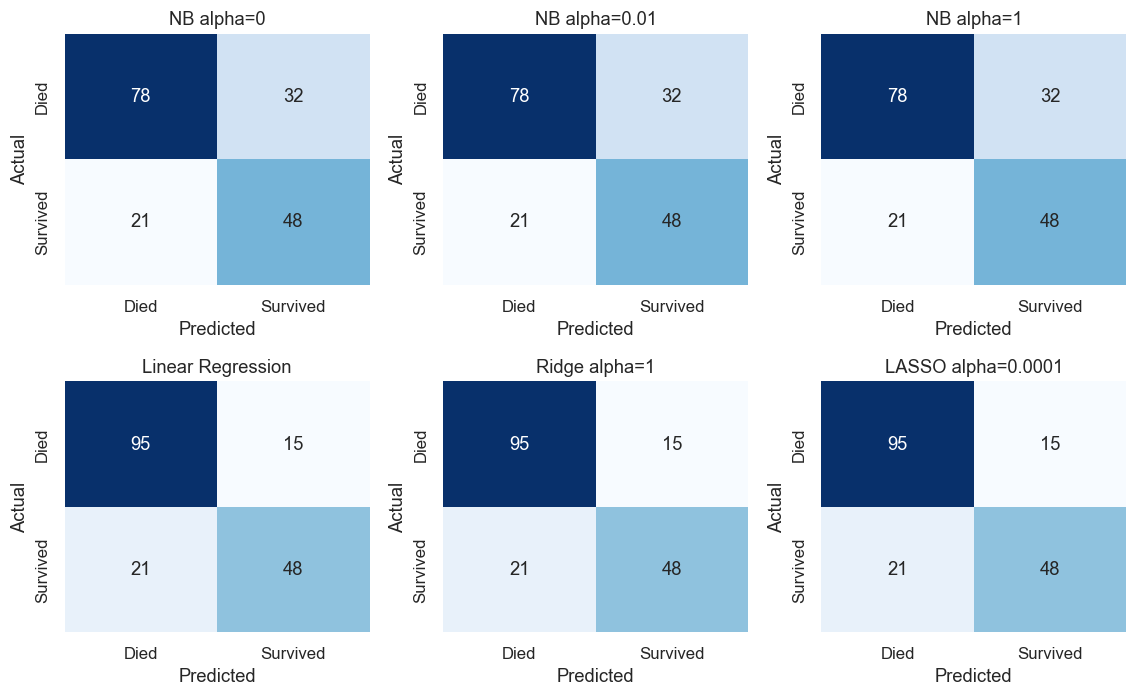

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(10.5, 6.5))
for ax, name in zip(axes.flat, evaluation_names):
    cm = confusion_matrix(y_test, holdout_predictions[name], labels=[0,1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Died','Survived'], yticklabels=['Died','Survived'])
    ax.set(title=name, xlabel='Predicted', ylabel='Actual')
show_figure('03_confusion_matrices.png')

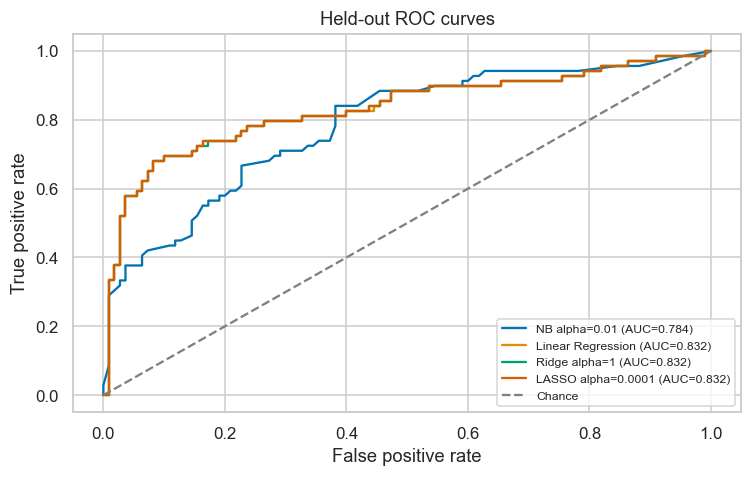

In [21]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for name in [best_nb, 'Linear Regression', best_ridge, best_lasso]:
    fpr, tpr, _ = roc_curve(y_test, holdout_scores[name])
    ax.plot(fpr, tpr, label=f"{name} (AUC={metrics.loc[name, 'AUC']:.3f})")
ax.plot([0,1], [0,1], '--', color='gray', label='Chance')
ax.set(xlabel='False positive rate', ylabel='True positive rate', title='Held-out ROC curves')
ax.legend(loc='lower right', fontsize=8)
show_figure('04_roc_curves.png')

### What changes with smoothing?
We compare both classification changes at 0.5 and changes in probability
estimates. Smoothing need not improve accuracy: it regularizes likelihoods,
and a small probability change may not cross the threshold. The exact zero-α
case can fail when a class has an all-zero or all-one feature. We check the
observed fitted probabilities instead of claiming that this always happens.

In [22]:
p0 = np.exp(fitted_models['NB alpha=0'].named_steps['model'].feature_log_prob_)
smooth_rows = []
for name in ['NB alpha=0.01', 'NB alpha=1']:
    smooth_rows.append({'Model': name,
        'Changed predictions vs alpha=0': int(np.sum(
            holdout_predictions[name] != holdout_predictions['NB alpha=0'])),
        'Mean absolute score change': float(np.mean(np.abs(
            holdout_scores[name] - holdout_scores['NB alpha=0']))),
        'Accuracy difference': float(metrics.loc[name, 'Accuracy'] -
                                     metrics.loc['NB alpha=0', 'Accuracy'])})
smoothing = pd.DataFrame(smooth_rows)
display(smoothing.round(6))
print('Unsmoothed feature probability range:', p0.min(), p0.max())
print('Exactly 0 or 1 probabilities:', int(np.sum((p0 == 0) | (p0 == 1))))
print('No nonfinite scores occurred in the training folds or holdout.')

,Model,Changed predictions vs alpha=0,Mean absolute score change,Accuracy difference
0,NB alpha=0.01,0,0.000011,0.0
1,NB alpha=1,0,0.001055,0.0


Unsmoothed feature probability range: 0.0706150341685649 0.8519362186788156
Exactly 0 or 1 probabilities: 0
No nonfinite scores occurred in the training folds or holdout.


In [23]:
reg_diagnostics = []
for name in ['Linear Regression', best_ridge, best_lasso]:
    scores = holdout_scores[name]
    coefs = fitted_models[name].named_steps['model'].coef_
    reg_diagnostics.append({'Model': name, 'Min score': scores.min(),
        'Max score': scores.max(), 'Outside [0,1]': int(np.sum((scores < 0)|(scores > 1))),
        'Nonzero coefficients': int(np.sum(np.abs(coefs) > 1e-10)),
        'L2 coefficient norm': float(np.linalg.norm(coefs))})
reg_diagnostics = pd.DataFrame(reg_diagnostics)
display(reg_diagnostics.round(4))

,Model,Min score,Max score,"Outside [0,1]",Nonzero coefficients,L2 coefficient norm
0,Linear Regression,-0.2673,1.0792,10,11,0.5468
1,Ridge alpha=1,-0.2638,1.0769,7,11,0.5435
2,LASSO alpha=0.0001,-0.2645,1.0787,9,11,0.5461


In [24]:
# Wilson interval reflects finite holdout size, not all sources of uncertainty.
def wilson_interval(correct, n, z=1.96):
    p = correct/n
    denom = 1 + z*z/n
    center = (p + z*z/(2*n))/denom
    half = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n))/denom
    return center-half, center+half

In [25]:
chosen_pred = holdout_predictions[selected_name]
accuracy_ci = wilson_interval(int(np.sum(chosen_pred == y_test.to_numpy())), len(y_test))
print('Selected-model approximate 95% Wilson accuracy interval:', accuracy_ci)
subgroup_rows = []
for sex in ['female', 'male']:
    mask = X_test_raw.Sex.eq(sex).to_numpy()
    subgroup_rows.append({'Sex': sex, 'n': int(mask.sum()),
        'Accuracy': accuracy_score(y_test.to_numpy()[mask], chosen_pred[mask]),
        'Survivor recall': recall_score(y_test.to_numpy()[mask], chosen_pred[mask],
                                        zero_division=0)})
subgroups = pd.DataFrame(subgroup_rows)
display(subgroups.round(4))

Selected-model approximate 95% Wilson accuracy interval: (0.7341634613765463, 0.851042531132817)


,Sex,n,Accuracy,Survivor recall
0,female,61,0.8033,1.000
1,male,118,0.7966,0.125


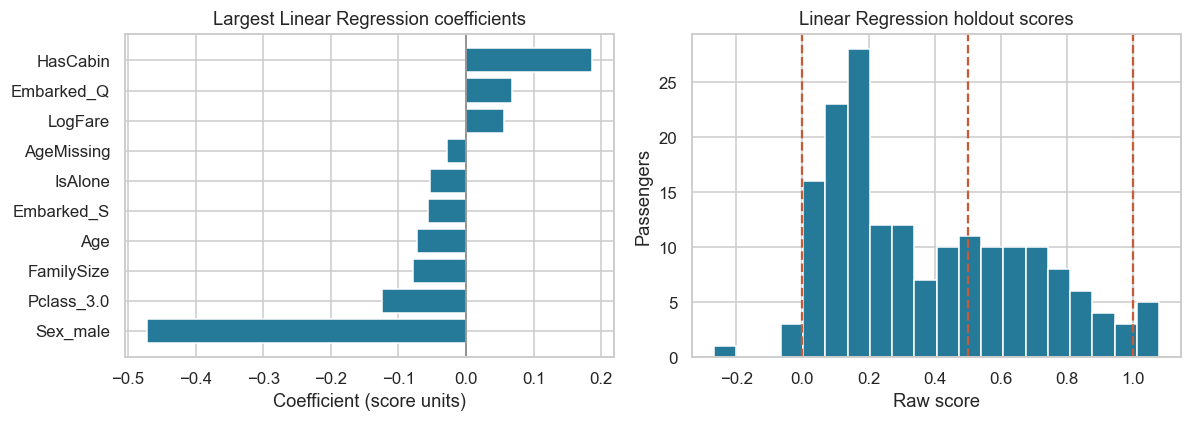

In [26]:
lr = fitted_models['Linear Regression']
coef = pd.Series(lr.named_steps['model'].coef_,
                 index=lr.named_steps['preprocess'].get_feature_names_out())
coef = coef.iloc[np.argsort(np.abs(coef.values))[-10:]].sort_values()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].barh([s.replace('numeric__','').replace('category__','').replace('flags__','')
             for s in coef.index], coef.values, color='#267a99')
axes[0].axvline(0, color='gray', linewidth=1)
axes[0].set(title='Largest Linear Regression coefficients', xlabel='Coefficient (score units)')
axes[1].hist(holdout_scores['Linear Regression'], bins=20, color='#267a99')
for v in [0, .5, 1]:
    axes[1].axvline(v, color='#c45c38', linestyle='--')
axes[1].set(title='Linear Regression holdout scores', xlabel='Raw score', ylabel='Passengers')
show_figure('05_regression_diagnostics.png')

## Step 5 — Interpretation, limitations, and reproducibility
The next cell summarizes the actual run rather than hard-coding a preferred
winner. A small holdout difference does not establish general superiority.
Fold standard deviations are variation across five overlapping training
experiments, not a confidence interval. The Wilson interval additionally
assumes independent test outcomes; relatives can make that assumption imperfect.

The models learn associations in a historical sample. Coefficients are not
causal effects. Cabin recording and fare can proxy passenger class; imputed
ages lose individual detail. Passengers sharing tickets or families may occur
on both sides of a random split, so a future group-based split would be a
stronger test of transfer to unrelated groups. Subgroup differences are
descriptive and based on small counts, not a complete fairness evaluation.

Linear Regression's unbounded scores and NB's correlated features limit
probability interpretation. Neither changing the threshold after examining
holdout labels nor reporting Kaggle example predictions as actual labels is
appropriate. The required 0.5 threshold remains fixed throughout.

In [27]:
chosen = metrics.loc[selected_name]
nb_delta = float(smoothing.loc[smoothing.Model.eq('NB alpha=1'), 'Accuracy difference'].iloc[0])
display(Markdown(f"""
**Training-CV selection:** {selected_name}.
Its holdout accuracy is **{chosen.Accuracy:.3f}**, survivor precision
**{chosen.Precision:.3f}**, recall **{chosen.Recall:.3f}**, F1 **{chosen.F1:.3f}**,
and AUC **{chosen.AUC:.3f}**. The majority baseline accuracy is
**{metrics.loc['Majority baseline','Accuracy']:.3f}**.
The approximate 95% accuracy interval is **{accuracy_ci[0]:.3f}–{accuracy_ci[1]:.3f}**.

Laplace smoothing (α=1) changed holdout accuracy by **{nb_delta:+.3f}** versus
the unsmoothed NB fit. The detailed table above distinguishes changed labels
from changes in probability estimates. The ablation table reports whether
engineering helped each model on training CV, even when a change is negative.
"""))


**Training-CV selection:** Ridge alpha=1.
Its holdout accuracy is **0.799**, survivor precision
**0.762**, recall **0.696**, F1 **0.727**,
and AUC **0.832**. The majority baseline accuracy is
**0.615**.
The approximate 95% accuracy interval is **0.734–0.851**.

Laplace smoothing (α=1) changed holdout accuracy by **+0.000** versus
the unsmoothed NB fit. The detailed table above distinguishes changed labels
from changes in probability estimates. The ablation table reports whether
engineering helped each model on training CV, even when a change is negative.


In [28]:
run_summary = {
    'seed': SEED, 'train_n': len(y_train), 'holdout_n': len(y_test),
    'train_survivors': int(y_train.sum()), 'holdout_survivors': int(y_test.sum()),
    'selected_model': selected_name, 'best_nb': best_nb,
    'best_ridge': best_ridge, 'best_lasso': best_lasso,
    'accuracy_ci': list(accuracy_ci), 'invalid_counts': invalid,
    'linear_features': int(encoded_train.shape[1]),
    'nb_features': int(nb_pre.transform(X_train).shape[1]),
    'nb_bins': nb_pre.named_transformers_['numeric'].named_steps['bins'].n_bins_.tolist(),
    'training_medians': example_pre.named_transformers_['numeric'].named_steps['impute'].statistics_.tolist(),
    'unsmoothed_probability_range': [float(p0.min()), float(p0.max())],
    'versions': {'python': platform.python_version(), 'numpy': np.__version__,
                 'pandas': pd.__version__, 'sklearn': sklearn.__version__}}
print('Results, figures, and version information are retained in this notebook.')

Results, figures, and version information are retained in this notebook.


## Optional Kaggle predictions
After the assignment evaluation is complete, refit the model selected by
training CV on all 891 labeled rows and predict the 418 unlabeled passengers.
This does not alter the previously reported holdout results. Predictions are displayed inline only; no Kaggle leaderboard score is claimed.

In [29]:
test_path = data_dir / 'test.csv'
if test_path.exists():
    kaggle_test = pd.read_csv(test_path)
    assert 'Survived' not in kaggle_test.columns
    final_model = clone(candidates[selected_name]).fit(clean_and_engineer(X_raw), y)
    final_scores = scores_from(final_model, clean_and_engineer(kaggle_test))
    submission = pd.DataFrame({'PassengerId': kaggle_test.PassengerId,
                              'Survived': (final_scores >= .5).astype(int)})
    assert len(submission) == len(kaggle_test)
    assert submission.PassengerId.is_unique
    assert submission.Survived.isin([0,1]).all()
    print('Computed', len(submission), 'predictions in memory; no ground-truth test evaluation is available.')
    display(submission.head())
else:
    print('Optional test.csv is absent; the assignment evaluation above is complete.')

Computed 418 predictions in memory; no ground-truth test evaluation is available.


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


## AI tool usage disclosure
**Tool used:** OpenAI Codex (ChatGPT coding assistant).

**AI contributions:** interpreted the assignment; inspected the provided CSVs;
proposed and implemented cleaning, transformations, training splits, model
comparisons, smoothing experiments, and evaluation; executed and checked the
notebook; generated plots and drafted the PDF analysis and disclosure.
Results come from running the supplied data, not invented numerical examples.

**Student contribution established in this session:** selected the Titanic
dataset, provided the assignment and local files, and requested completion.
Independent implementation, interpretation, and full code review by the
student have not been verified. Before submitting, the student should read
every block, explain the design choices, verify the findings, and update this
disclosure with only work they actually performed. Do not describe AI-written
analysis or code as independently authored work.

### References
- Assignment 1: From Dirty Data to Predictive Models, supplied course handout.
- [Kaggle Titanic data and variable definitions](https://www.kaggle.com/competitions/titanic/data).
- [scikit-learn BernoulliNB documentation](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.BernoulliNB.html).
- [scikit-learn LinearRegression documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).
- [scikit-learn leakage and preprocessing guidance](https://scikit-learn.org/stable/common_pitfalls.html).

### Submission checks
- Restart and run all cells; confirm there are no errors.
- Upload this executed notebook to Colab and enable the required sharing access.
- Insert its actual link on page 1 of the 11-page report; verify that it opens.
- Review the notebook and report, and record your own subsequent contributions.
- Submit the `.ipynb` and PDF; keep code out of the PDF, including appendices.